<a href="https://colab.research.google.com/github/ezNobson/Monte-Carlo-Black-Scholes/blob/main/MC_Black_Scholes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Estimating the price of a European Call option using Monte Carlo simulation.**
---
Autor: Michał Dyrek

Calculate option price using Monte Carlo and Geometric Brownian Motion (GBM) and prepare results with the analytical solutions using Black-Scholes model.

## **1.) Prepare needed functions.**

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
def get_market_data(ticker, period="1y"):
  """
  Download stock data and calculates its actual price and historical volatility.
  """
  df = yf.download(ticker, period=period)

  if isinstance(df.columns, pd.MultiIndex):
        close_prices = df['Close'][ticker]
  else:
        close_prices = df['Close']


  # Calculates log return and yearly volatility (sigma)
  log_returns = np.log(close_prices / close_prices.shift(1))
  sigma = float(log_returns.std() * np.sqrt(252))  # 252 -> trading days -> annual volatility
  s0 = float(close_prices.iloc[-1])

  return s0, close_prices, sigma

In [3]:
def monte_carlo_option_pricing(S0, K, T, r, sigma, iterations = 50000):
    """
    Estimates the price of a European Call option using Monte Carlo simulation.

    This function simulates multiple potential price paths for an asset following
    Geometric Brownian Motion to determine the expected payoff.

    Parameters:
    -----------
    S0 : float
        Current asset price.
     K : float
        Strike price (the price at which the option holder can buy the asset).
     T : float
        Time to maturity in years (example: 0.5 for six months).
     r : float
        Risk-free interest rate (annualized, example: 0.05 for 5%). Its our drift
     sigma : float
        Annualized volatility of the underlying asset (historical or implied).
    iterations : int, optional
        Number of simulated price paths. Higher values increase precision (default: 50,000).

     Returns:
     -------
     option_price : float
        The estimated present value (fair price) of the European Call option.
     ST : numpy.ndarray
         An array of simulated terminal asset prices at time T.
    """

    # Generating random paths using Geometric Brownian Motion
    z = np.random.standard_normal(iterations)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z)   # Brownian Motion Equation

    # Payoff function for a Call option:
    payoffs = np.maximum(ST - K, 0)   # Simple If St>K then we call option and earn, otherwise we do not use the option to buy

    # Discounting the average payoff to the present value
    option_price = np.exp(-r * T) * np.mean(payoffs)

    return option_price, ST

In [4]:
def black_scholes_analytical(S0, K, T, r, sigma):
    """Calculates analytically price of an option CALL using the classic Black-Scholes formula"""
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call_price = (S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2))
    return call_price

In [5]:
def generate_full_paths(S0, T, r, sigma, iterations=1000, steps=100):
    """
    SUPPLEMENTARY FUNCTION: Generates 2D matrix for the fan chart.
    Needed for advanced plotting (confidence intervals).
    """
    dt = T / steps
    paths = np.zeros((steps + 1, iterations))
    paths[0] = S0
    for t in range(1, steps + 1):
        z = np.random.standard_normal(iterations)
        paths[t] = paths[t-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)
    return paths

In [6]:
def plot_advanced_analysis(ticker, history, S0, K, full_paths, terminal_prices):
    """
    Visualizes the results without AxisError.
    """
    fig = plt.figure(figsize=(15, 10))

    # 1. Fan Chart (requires 2D matrix)
    ax1 = plt.subplot(2, 2, (1, 2))
    upper_95 = np.percentile(full_paths, 95, axis=1) # Works because axis=1 exists here
    lower_5 = np.percentile(full_paths, 5, axis=1)
    ax1.plot(full_paths[:, :50], color='blue', alpha=0.1) # Sample paths
    ax1.plot(np.mean(full_paths, axis=1), color='darkblue', lw=2, label='Expected Drift')
    ax1.fill_between(range(len(upper_95)), lower_5, upper_95, color='blue', alpha=0.15, label='90% Confidence Interval')
    ax1.axhline(K, color='red', linestyle='--', label=f'Strike Price (K={K:.2f})')
    ax1.set_title(f"Monte Carlo Simulation Paths for {ticker}")
    ax1.set_xlabel("Time Steps (Trading Days)")
    ax1.set_ylabel("Stock Price (USD)")
    ax1.legend()

    # 2. Histogram (using terminal prices)
    ax2 = plt.subplot(2, 2, 3)
    ax2.hist(terminal_prices, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    ax2.axvline(K, color='red', label='Strike')
    ax2.set_xlabel("Terminal Price (S_T)")
    ax2.set_ylabel("Frequency")
    ax2.set_title("Distribution of Final Prices ($S_T$)")
    ax2.legend()

    # 3. History
    ax3 = plt.subplot(2, 2, 4)
    ax3.plot(history[-100:].values, color='green')
    ax3.set_title("Historical Performance (Last 100 Days)")

    plt.tight_layout()
    plt.show()

In [7]:
ticker = 'NVDA' # Stock of an Nvidia
T = 0.5         # 6 months
r = 0.045       # Return 4.5%
K_REL = 1.05    # Strike price 5% over actual price

## Download the data

In [8]:
s0, history, sigma = get_market_data(ticker)
k = s0 * K_REL

/tmp/ipykernel_3839/3676404382.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period)
[*********************100%***********************]  1 of 1 completed


Monte carlo solution

In [9]:
mc_price, st_path = monte_carlo_option_pricing(s0, k, T, r, sigma)

Black-Scholes solution

In [10]:
bs_price = black_scholes_analytical(s0, k, T, r, sigma)

In [11]:
print(f" Results for {ticker}:")
print(f" - Actual Price (S0): {s0:.2f}")
print(f" - Strike price (K): {k:.2f}")
print(f" - Volatility (Sigma): {sigma:.2%}")
print("-" * 30)
print(f" - Pricing Monte Carlo: {mc_price:.4f}")
print(f" - Pricing Black-Scholes: {bs_price:.4f}")
print(f" - Difference: {abs(mc_price - bs_price):.6f}")

 Results for NVDA:
 - Actual Price (S0): 167.52
 - Strike price (K): 175.90
 - Volatility (Sigma): 40.65%
------------------------------
 - Pricing Monte Carlo: 17.1885
 - Pricing Black-Scholes: 17.2484
 - Difference: 0.059934


Let's see for 100 000 iterations

In [12]:
mc_price_100, st_path_100 = monte_carlo_option_pricing(s0, k, T, r, sigma, iterations =100000)

In [13]:
print(f" Results for {ticker}:")
print(f" - Actual Price (S0): {s0:.2f}")
print(f" - Strike price (K): {k:.2f}")
print(f" - Volatility (Sigma): {sigma:.2%}")
print("-" * 30)
print(f" - Pricing Monte Carlo: {mc_price_100:.4f}")
print(f" - Pricing Black-Scholes: {bs_price:.4f}")
print(f" - Difference: {abs(mc_price_100 - bs_price):.6f}")

 Results for NVDA:
 - Actual Price (S0): 167.52
 - Strike price (K): 175.90
 - Volatility (Sigma): 40.65%
------------------------------
 - Pricing Monte Carlo: 17.3150
 - Pricing Black-Scholes: 17.2484
 - Difference: 0.066588


In [14]:
iterations_range = [100, 500, 1000, 5000, 10000, 50000, 100000]
errors = []

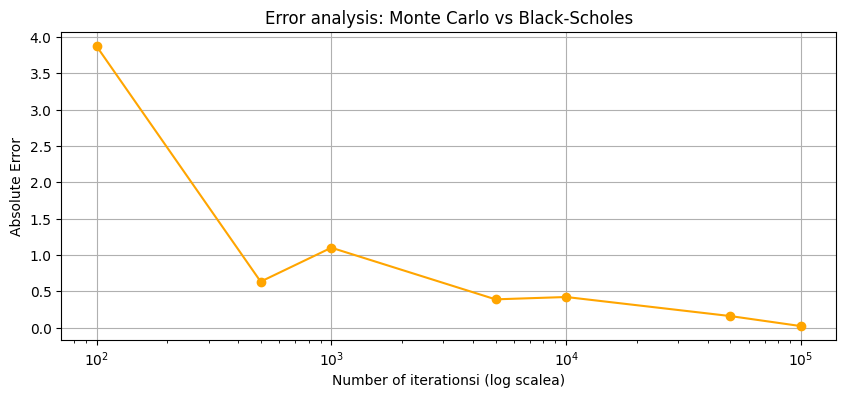

In [15]:
for i in iterations_range:
    temp_price, _ = monte_carlo_option_pricing(s0, k, T, r, sigma, iterations=i)
    errors.append(abs(temp_price - bs_price))

plt.figure(figsize=(10, 4))
plt.plot(iterations_range, errors, marker='o', linestyle='-', color='orange')
plt.xscale('log')
plt.title("Error analysis: Monte Carlo vs Black-Scholes")
plt.xlabel("Number of iterationsi (log scalea)")
plt.ylabel("Absolute Error")
plt.grid(True)
plt.show()

In [16]:
full_paths_for_viz = generate_full_paths(s0, T, r, sigma, iterations=1000)

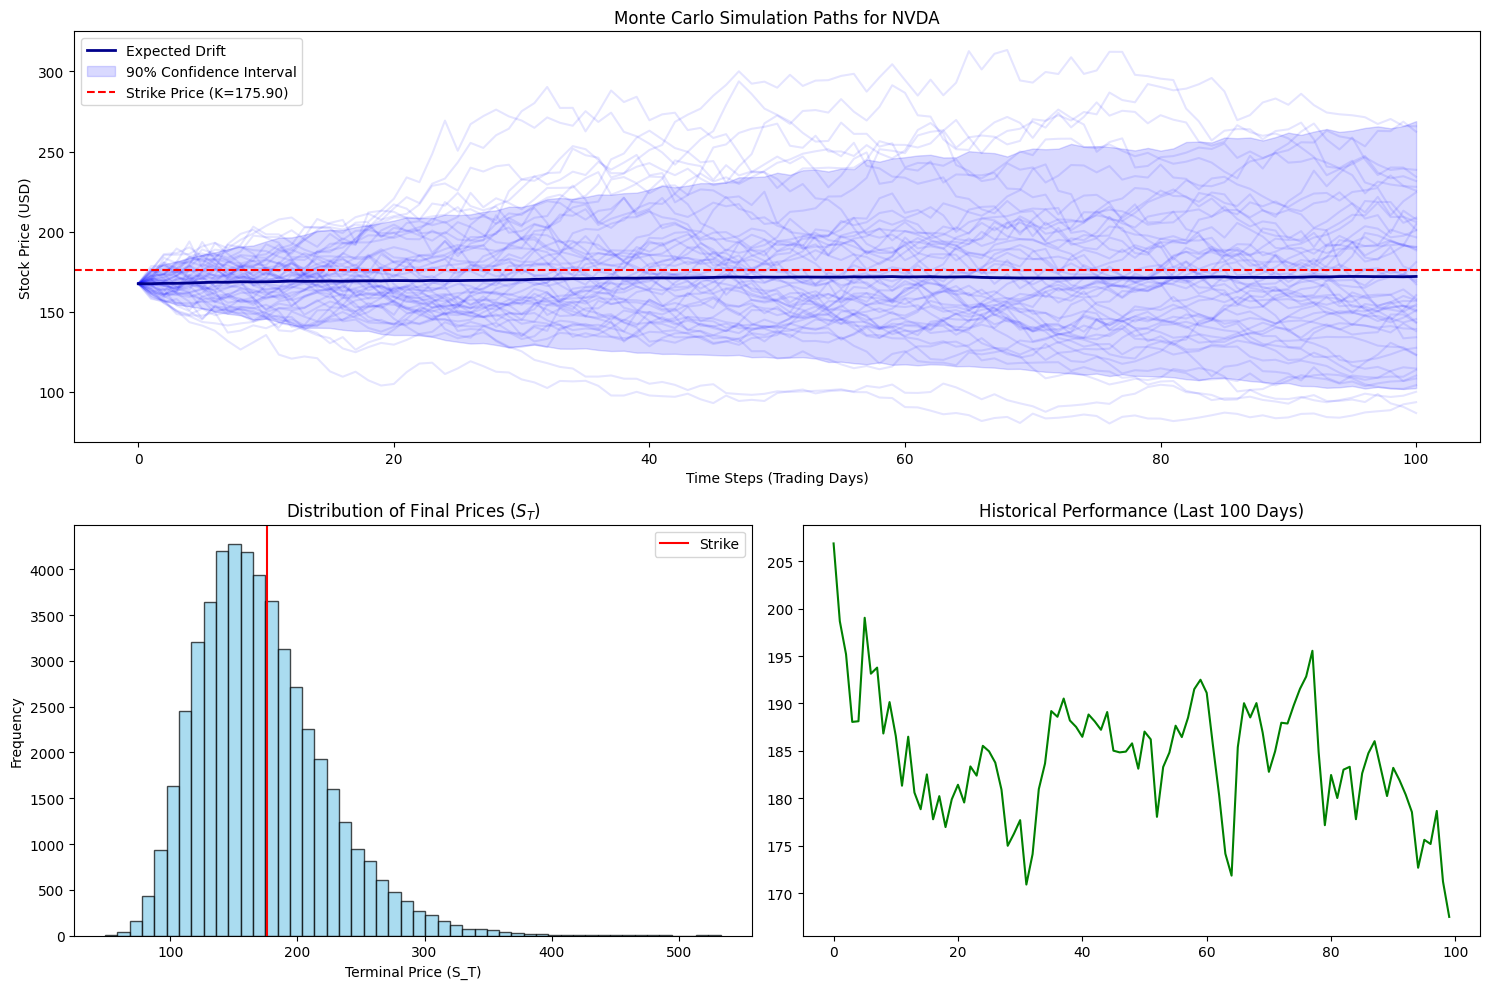

In [17]:
plot_advanced_analysis(ticker, history, s0, k,full_paths_for_viz, st_path )

## Conclusion
The project successfully demonstrated the application of **Monte Carlo (MC) simulations** in the field of quantitative finance. The key findings are summarized below:
  - **Model Accuracy & Convergence:** The simulation results showed high convergence with the analytical **Black-Scholes** price. As the number of iterations increased to 100,000, the absolute error became negligible, validating the robustness of the stochastic approach and **the Law of Large Numbers**.
  - **Stochastic Dynamics:** Through the "Fan Chart" visualization, we observed how price uncertainty (variance) evolves over time following **Geometric Brownian Motion (GBM)**. The log-normal distribution of terminal prices confirms that while assets can theoretically reach high values, they are naturally bounded at zero.
  - **Practical Application:** By integrating real-market data (NVIDIA) via the yfinance API, the model transformed from a theoretical exercise into a functional analytical tool capable of estimating **Historical Volatility ($\sigma$)** and fair option premiums in real-time.
  - **Computational Efficiency:** Utilizing vectorized operations allowed for the efficient processing of thousands of potential market scenarios in milliseconds, highlighting the power of computational intelligence in handling high-dimensional financial problems.

**Final Remark:** While the Black-Scholes formula provides an instant solution for simple European options, the **Monte Carlo method** remains superior in professional environments due to its flexibility in pricing complex "exotic" derivatives where no analytical formula exists.

## Added CVaR stats

In [18]:
def calculate_risk_metrics(S0, ST, alpha=0.95):
    """
    Calculates VaR and CVaR for the simulated stock price paths.

    Parameters:
    ST (ndarray): Array of simulated terminal prices.
    alpha (float): Confidence level (e.g., 0.95 for 95%).
    """
    # Calcualtes Losses as a difference between opening and closing price
    # Positive value means loss (S0 > ST)
    losses = S0 - ST

    # 1. VaR (Value at Risk) percentile of a loss
    var = np.percentile(losses, alpha * 100)

    # 2. CVaR (Conditional VaR) mean from all the losses greater then VaR
    cvar = losses[losses > var].mean()

    return var, cvar

In [19]:
var_95, cvar_95 = calculate_risk_metrics(s0, st_path, alpha=0.95)

print(f"Risk Analysis (95% Confidence):")
print(f"Value at Risk (VaR):  {var_95:.2f} USD")
print(f"Conditional VaR (CVaR): {cvar_95:.2f} USD")

Risk Analysis (95% Confidence):
Value at Risk (VaR):  64.33 USD
Conditional VaR (CVaR): 75.43 USD


For the $95\%$ level of confidance:
  - **VaR (64.33 USD):** Means that with a probability of $95\%$ loss on once stock of NVDA will not exceed $64.33$ USD over the next 6 months. There is only a 5% chance that the loss will be greater than this amount.
  - **Conditional Value at Risk (CVaR)** = $75.43: Also known as Expected Shortfall, this is the "average of the worst-case scenarios." If the stock performs poorly and hits that 5% "tail" of the distribution (losing more than $64.33), the average loss in those extreme cases will be $75.43.


In [20]:
var_99, cvar_99 = calculate_risk_metrics(s0, st_path, alpha=0.99)

print(f"Risk Analysis (99% Confidence):")
print(f"Value at Risk (VaR):  {var_99:.2f} USD")
print(f"Conditional VaR (CVaR): {cvar_99:.2f} USD")

Risk Analysis (99% Confidence):
Value at Risk (VaR):  82.78 USD
Conditional VaR (CVaR): 90.22 USD


### **Comparison: 95% vs. 99% Confidence**
As we increase the confidence level to 99%, the metrics naturally increase:

VaR (99%) = $82.78

CVaR (99%) = $90.22

This indicates that as we look at even rarer "black swan" events (the worst 1% of outcomes), the potential losses grow significantly.